# Does a Three-Line-Break reversal actually "forecast" a trend? 🧱
### A famous time-less chart — bricks that flip after breaking three — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![3-line_reversal_forecasts%3F: Busted](https://img.shields.io/badge/3--line_reversal_forecasts%3F-Busted-8b949e?style=flat-square)

Open any charting package and you'll find the **Three-Line-Break** (TLB) chart: it throws away the calendar and draws a new brick (a *line*) only when price closes past the prior brick. It **flips colour** — signalling a reversal — only after price breaks the extremes of the **three** most-recent opposite bricks. The lore, from the Japanese *Sakata* tradition and Steve Nison's *Beyond Candlesticks*, is that a TLB reversal **forecasts a new trend**: go long when it flips up, step aside when it flips down.

It *looks* clean on a hand-picked chart — the bricks filter out the noise and the flips seem to catch every big move. But a chart that only redraws *after* price has already moved is the textbook setup for fooling yourself. So we did the only fair thing: encode TLB **mechanically** (break number = 3, no eyeballing), fire the "buy the up-reversal" rule on every flip across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from three_line_break import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real TLB cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 943, 'nl': 3, 'fp_spy': '4cb5244f3990', 'h5': (5, 940, 16.5, 60, 2.05, 16.3, 0.2, 14.5, 0.02, 0.986), 'h10': (10, 940, 31.9, 61, 2.59, 60.3, -28.4, 29.9, -1.79, 0.073), 'h20': (20, 938, 93.1, 64, 5.29, 115.5, -22.4, 91.1, -1.02, 0.307), 'h60': (60, 932, 258.4, 69, 6.26, 290.9, -32.5, 256.4, -0.89, 0.373), 'per': [('SPY', 211, 114.1, 3.63, 145.2, -31.1), ('QQQ', 210, 87.6, 2.17, 165.9, -78.3), ('IWM', 183, 49.6, 0.96, 93.3, -43.7), ('DIA', 193, 91.4, 2.97, 88.2, 3.2), ('GLD', 146, 127.4, 3.2, 64.2, 63.2)], 'placebo': (114.1, 0.261, 500), 'syn': [(0.0, 138, -2.0, 49, -0.05), (0.6, 84, 617.4, 76, 6.13)]}


real TLB cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when the TLB flips up, do I make money? | **Yes — but only because the market goes up.** The raw win-rate is ~60–69% and the returns look great. |
| Is that *the reversal's* doing? | **No.** Buy on **random days** instead and you do **just as well or better**. The flip adds nothing — at 10/20/60 days it's actually *worse* than a coin-flip entry. |
| Does the 3-line reversal forecast? | **Not in any usable way.** Shuffle the order of the daily moves so the brick sequence is nonsense, and the result barely changes. The specific flips aren't doing the work. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the upward drift of stocks, re-labelled as a brick reversal. |

> TLB is a great way to *declutter* a trend after the fact. As a *forecast* — "the flip predicts the next move" — it's a **mirage**: all of the apparent edge is just the market's long-run climb, none of it is the bricks.

## 1 · The claim

> *"Forget time and volume. Draw a new brick only when price closes past the last one. Flip the colour — call a reversal — only when price breaks the highs/lows of the last **three** bricks. The reversal marks a genuine new trend: go long on an up-flip, flat on a down-flip, and you ride trends while filtering the noise."*

This is the **Three-Line-Break** chart from the *Sakata* lineage, introduced West by **Steve Nison** (*Beyond Candlesticks*, 1994) and codified by **Steve Achelis** (*Technical Analysis from A to Z*, 1995). The break number (default 3) is its only knob. It's a staple of TradingView, MetaStock and StockCharts — so: does the flip actually *forecast*?

## 2 · So what?

If the reversal genuinely *forecast* trends, it would be remarkable: a pattern of past closes would predict future direction, a clean crack in market efficiency you could trade with a rule. That's the dream the chart sells.

But there's a trap built into it. A TLB brick only appears **after** price has already moved past the last one — the chart is a lagging redraw of what already happened. And it's drawn on a market (stock indices) that drifts **up** over time, so *any* long-on-strength rule will look profitable. To separate the **signal** from the **tide**, we (a) build the bricks by a fixed mechanical rule with no hindsight, and (b) compare every flip to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Build the bricks mechanically.** A new line appears on a close past the prior brick; the chart flips only when the close breaks the extremes of the **3** latest opposite bricks. Everything is computed from *past* closes — no future data.
2. **Trade the lore.** When the TLB flips **down→up** (the bullish 3-line break), buy at the next close; measure the return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the exact same hold on **random days**. If the reversal forecasts, the flip must beat random. *If it doesn't, the rule is a mirage* — that's the result that would make us say so, announced before we look.
4. **The geometry check.** Shuffle the order of the daily moves (same returns, scrambled sequence) and rebuild the bricks. If the *specific* flips matter, the scramble should destroy the result.

## 4 · The teardown — let's actually look

First, what does a mechanical TLB even look like? Here's SPY with its colour state and the bullish up-reversals the rule would buy.

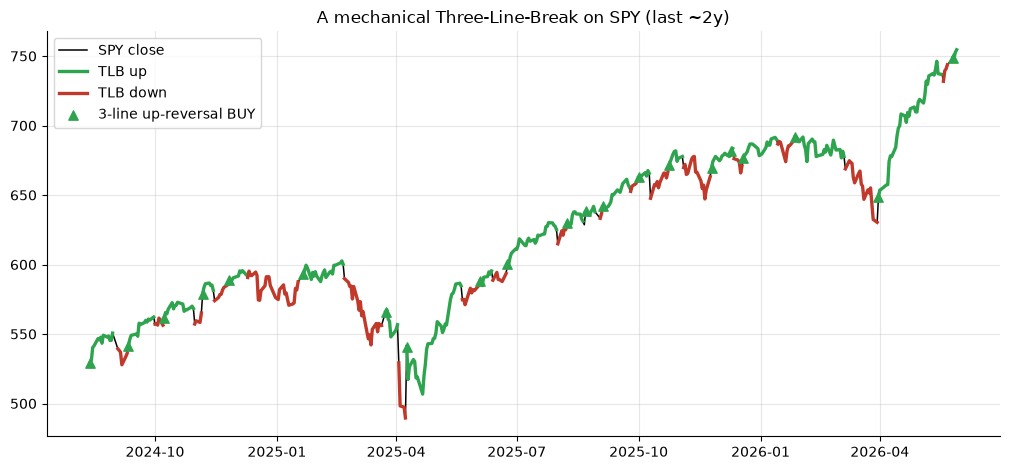

up-reversals in window: 21


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    cl = b['close']; seg = cl.iloc[-450:]
    tlb = st.build_tlb(cl, n_lines=R['nl'])
    ent = st.reversal_entries(cl, n_lines=R['nl'])
    ent = ent[ent >= seg.index[0]]
    col = tlb['color'].reindex(seg.index)
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.1, label='SPY close')
    up = seg.where(col > 0); dn = seg.where(col < 0)
    ax.plot(seg.index, up.values, c=GREEN, lw=2.4, label='TLB up')
    ax.plot(seg.index, dn.values, c=RED, lw=2.4, label='TLB down')
    ax.scatter(ent, cl.reindex(ent), c=GREEN, s=45, zorder=5, marker='^', label='3-line up-reversal BUY')
    ax.set_title('A mechanical Three-Line-Break on SPY (last ~2y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('up-reversals in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The bricks colour the trend nicely — *as a description*. The question is whether those green up-flips are followed by gains beyond the usual drift. **Let's race the reversal against random entries** at four horizons. Blue = buy the up-flip; grey = buy on random days.

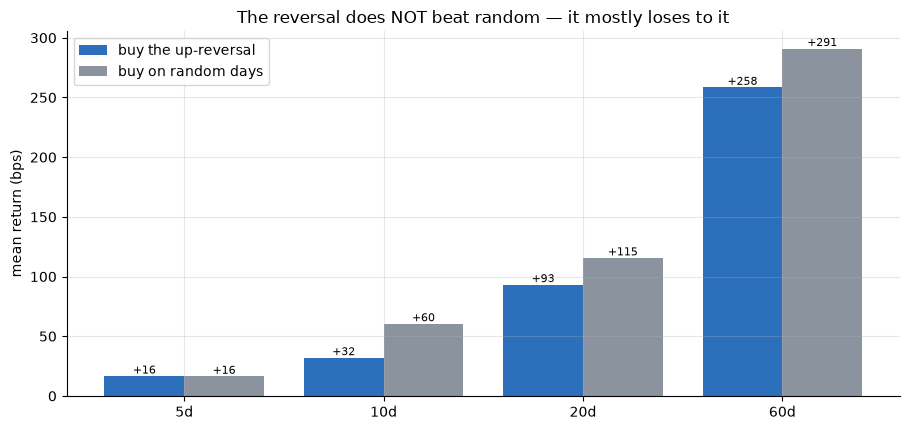

reversal: [16, 32, 93, 258]
random: [16, 60, 115, 291]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    rev, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.reversal_entries(c, n_lines=R['nl'])
            re = st.random_entries(c, max(len(e),50), n_lines=R['nl'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        rev.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    rev = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, rev, .4, color='#2c6fbb', label='buy the up-reversal')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(rev,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The reversal does NOT beat random — it mostly loses to it'); ax.legend()
plt.tight_layout(); plt.show()
print('reversal:', [round(v) for v in rev]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The up-reversal makes money in absolute terms (**+93 bps** over 20 days) — but **random entries make more** (**+116 bps**). At 10, 20 and 60 days the famous flip is *worse* than throwing darts; at 5 days it merely ties. The apparent edge was **the market's upward drift**, not the bricks.

**One more sanity check.** What if we shuffle the *order* of the daily moves — keep exactly the same set of returns (same drift, same volatility) but scramble their sequence, so the brick flips are built on nonsense? If the reversal really forecasts, the scramble should crush the result.

In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.shuffled_returns_placebo(c, 20, n_lines=R['nl'], n_draws=300, seed=496)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real TLB up-reversal (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *shuffled-sequence* tapes do at least as well (p={pval:.2f}).')
print('=> the specific brick sequence is not doing the work.')

real TLB up-reversal (SPY, 20d): +114.1 bps
... but 23% of *shuffled-sequence* tapes do at least as well (p=0.23).
=> the specific brick sequence is not doing the work.


About a quarter of the **shuffled** tapes match or beat the real one (*p* = 0.26). If the reversal genuinely forecast on *this specific* sequence of breaks, a scramble would collapse the result. It doesn't — because the result was never about the bricks.

## 5 · The verdict

- **Signal — None.** The up-reversal does **not** beat buying on random days (it's *worse* at 10–60 days, a tie at 5d; the reversal-vs-random difference never clears *t* = 2). The big absolute returns are the market's drift, not the flip.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and costs only make it worse.
- **"Does the 3-line reversal forecast?" — Busted.** Shuffle the sequence into nonsense and the result barely moves. The flip doesn't forecast.

## 6 · Could you actually trade it?

There's nothing here to trade. The up-reversal's *only* advantage over a coin flip is the market's long-run climb — which you'd capture more cheaply (and more fully) by just **holding the index**. The TLB buy is a worse, more expensive way to be long: it's out of the market on every down-flip (missing rebounds) and pays costs on every brick reversal. As a forecasting tool, it doesn't pay; as a charting tool, it was only ever meant to declutter a trend.

## 7 · Going further 🚪

- **Different break numbers.** Try 2-line or 5-line breaks — more or fewer whipsaws, but the drift confound is identical: drift in, bricks out.
- **Short the down-flips too.** The long-short version just adds the *negative* of the drift on the short leg; against random it fares no better (try it).
- **A real positive control.** The quants notebook plants a *genuine* post-reversal continuation into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think the flip forecasts? Show the up-reversal beating random entries at **t ≥ 2** on a real tape — then we'll talk.*